<a href="https://colab.research.google.com/github/itsCodingCasper/satellite-image-classification/blob/main/Deforestation_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import cv2
import rasterio

import torch
import torch.nn as nn
from torchvision import models, transforms

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Study/Satellite_img_classifier"

MODEL_PATH = os.path.join(PROJECT_DIR, "best_model.pth")

IMAGE_2018_PATH = os.path.join(PROJECT_DIR, "amazon_2018.tif")
IMAGE_2025_PATH = os.path.join(PROJECT_DIR, "amazon_2025.tif")

print("Model :", MODEL_PATH)
print("2018  :", IMAGE_2018_PATH)
print("2025  :", IMAGE_2025_PATH)

Model : /content/drive/MyDrive/Study/Satellite_img_classifier/best_model.pth
2018  : /content/drive/MyDrive/Study/Satellite_img_classifier/amazon_2018.tif
2025  : /content/drive/MyDrive/Study/Satellite_img_classifier/amazon_2025.tif


In [ ]:
class_names = [
    'SeaLake',
    'River',
    'Residential',
    'PermanentCrop',
    'Pasture',
    'Industrial',
    'Highway',
    'HerbaceousVegetation',
    'Forest',
    'AnnualCrop'
]

num_classes = len(class_names)

print(class_names)

['SeaLake', 'River', 'Residential', 'PermanentCrop', 'Pasture', 'Industrial', 'Highway', 'HerbaceousVegetation', 'Forest', 'AnnualCrop']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
model = models.resnet50(weights=None)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, num_classes)

In [ ]:

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)

model.eval()

print("--------------------------------")
print("Model Loaded Successfully")
print("--------------------------------")
print("Best Validation Accuracy :", checkpoint["accuracy"])
print("Saved Epoch :", checkpoint["epoch"])

--------------------------------
Model Loaded Successfully
--------------------------------
Best Validation Accuracy : 0.9562616822429907
Saved Epoch : 5


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Inspect GeoTIFF Metadata


In [ ]:
src2018 = rasterio.open(IMAGE_2018_PATH)
src2025 = rasterio.open(IMAGE_2025_PATH)

print("========== 2018 ==========")
print("Width      :", src2018.width)
print("Height     :", src2018.height)
print("Bands      :", src2018.count)
print("CRS        :", src2018.crs)
print("Resolution :", src2018.res)
print()

print("========== 2025 ==========")
print("Width      :", src2025.width)
print("Height     :", src2025.height)
print("Bands      :", src2025.count)
print("CRS        :", src2025.crs)
print("Resolution :", src2025.res)

print("Number of bands:", src2018.count)

========== 2018 ==========
Width      : 1040
Height     : 840
Bands      : 26
CRS        : EPSG:32720
Resolution : (10.0, 10.0)

========== 2025 ==========
Width      : 1040
Height     : 840
Bands      : 26
CRS        : EPSG:32720
Resolution : (10.0, 10.0)
Number of bands: 26


Convert GeoTIFF to RGB NumPy Array

In [ ]:
# ============================================================
# CELL 11 : Read RGB Bands (B4, B3, B2)
# ============================================================

# Sentinel-2 RGB = B4 (Red), B3 (Green), B2 (Blue)

red2018   = src2018.read(4)
green2018 = src2018.read(3)
blue2018  = src2018.read(2)

red2025   = src2025.read(4)
green2025 = src2025.read(3)
blue2025  = src2025.read(2)

img2018 = np.dstack((red2018, green2018, blue2018))
img2025 = np.dstack((red2025, green2025, blue2025))

print(img2018.shape)
print(img2025.shape)

(840, 1040, 3)
(840, 1040, 3)


In [ ]:
# ============================================================
# CELL 12 : Pixel Statistics
# ============================================================

print("2018")

print("Minimum :", np.nanmin(img2018))
print("Maximum :", np.nanmax(img2018))

print()

print("2025")

print("Minimum :", np.nanmin(img2025))
print("Maximum :", np.nanmax(img2025))

2018
Minimum : 0.0028
Maximum : 0.3672

2025
Minimum : 0.0031
Maximum : 0.5468


In [ ]:
# ============================================================
# CELL 13 : Clean Image
# ============================================================

img2018 = np.nan_to_num(img2018)

img2025 = np.nan_to_num(img2025)

img2018 = np.clip(img2018, 0, 1)

img2025 = np.clip(img2025, 0, 1)

print("NaNs removed.")

NaNs removed.


Visualize Images

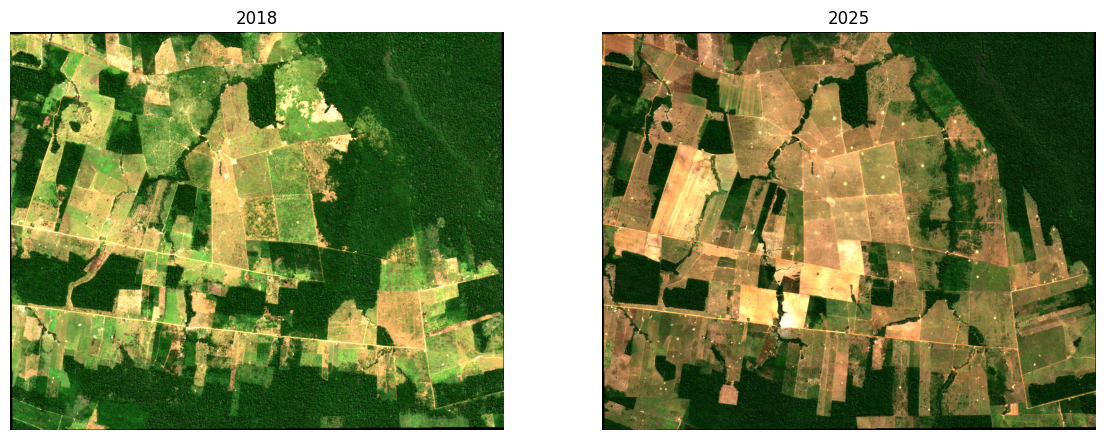

In [ ]:

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(stretch(img2018))
plt.title("2018")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stretch(img2025))
plt.title("2025")
plt.axis("off")

plt.show()

In [ ]:
def stretch(image):
    p2 = np.percentile(image, 2)
    p98 = np.percentile(image, 98)
    image = np.clip((image - p2) / (p98 - p2), 0, 1)
    return image


Patch shape: (124, 124, 3)


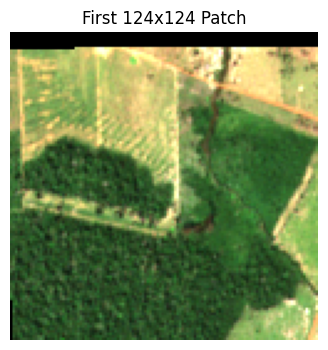

In [ ]:
# ============================================================
# CELL 15 : Extract One Patch
# ============================================================

PATCH_SIZE = 124

x = 0
y = 0

patch = img2018[
    y:y+PATCH_SIZE,
    x:x+PATCH_SIZE
]

print("Patch shape:", patch.shape)

plt.figure(figsize=(4,4))
plt.imshow(stretch(patch))
plt.title("First 124x124 Patch")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# CELL 16 : Patch Extraction Function
# ============================================================

def extract_patches(image, patch_size=124):
    """
    Extract non-overlapping patches and
    remember their coordinates.
    """

    patches = []
    metadata = []

    height, width, _ = image.shape

    for y in range(0, height - patch_size + 1, patch_size):

        for x in range(0, width - patch_size + 1, patch_size):

            patch = image[
                y:y+patch_size,
                x:x+patch_size
            ]

            patches.append(patch)

            metadata.append({
                "x": x,
                "y": y
            })

    return patches, pd.DataFrame(metadata)

In [ ]:
# ============================================================
# CELL 17 : Extract All Patches
# ============================================================

patches2018, meta2018 = extract_patches(img2018)

patches2025, meta2025 = extract_patches(img2025)

print("2018 patches:", len(patches2018))
print("2025 patches:", len(patches2025))

2018 patches: 48
2025 patches: 48


In [ ]:
# ============================================================
# CELL 19 : Predict One Patch
# ============================================================

patch = patches2018[0]

# Convert NumPy -> PIL
patch_pil = Image.fromarray((patch * 255).astype(np.uint8))

# Apply inference transform
input_tensor = transform(patch_pil).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(input_tensor)
    prediction = torch.argmax(outputs, dim=1).item()

print("Predicted Class :", class_names[prediction])

Predicted Class : AnnualCrop


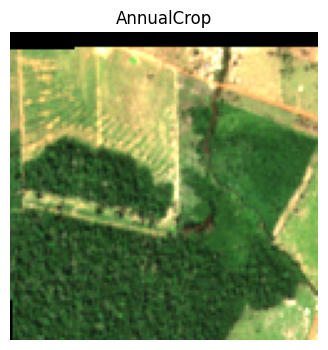

In [ ]:
# ============================================================
# CELL 20 : Display Prediction
# ============================================================

plt.figure(figsize=(4,4))

plt.imshow(stretch(patch))
plt.axis("off")

plt.title(class_names[prediction])

plt.show()

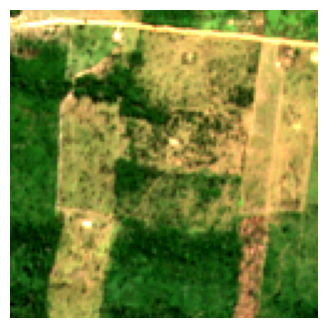


AnnualCrop : 0.8617
Forest : 0.1344
SeaLake : 0.0039
River : 0.0000
Residential : 0.0000


In [ ]:
# ============================================================
# CELL 21 : Predict All Patches
# ============================================================

import torch.nn.functional as F

patch = random.choice(patches2018)

patch_pil = Image.fromarray((patch * 255).astype(np.uint8))

input_tensor = transform(patch_pil).unsqueeze(0).to(device)

with torch.no_grad():

    logits = model(input_tensor)

    probs = F.softmax(logits, dim=1)

top5_prob, top5_idx = torch.topk(probs,5)

plt.figure(figsize=(4,4))
plt.imshow(stretch(patch))
plt.axis("off")
plt.show()

print()

for p,idx in zip(top5_prob[0],top5_idx[0]):

    print(f"{class_names[idx]} : {p.item():.4f}")

In [ ]:
# ============================================================
# CELL 22 : Run Inference
# ============================================================

def predict_patches(patches):
    predictions = []
    confidences = []
    for patch in patches:
        patch_pil = Image.fromarray((patch * 255).astype(np.uint8))
        input_tensor = transform(patch_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted_class = torch.max(probabilities, 1)
            predictions.append(predicted_class.item())
            confidences.append(confidence.item())
    return predictions, confidences


pred2018, conf2018 = predict_patches(patches2018)

pred2025, conf2025 = predict_patches(patches2025)

print("Inference Complete")

Inference Complete


In [ ]:
# ============================================================
# CELL 23 : Store Results
# ============================================================

meta2018["prediction"] = [
    class_names[i] for i in pred2018
]

meta2018["confidence"] = conf2018

meta2025["prediction"] = [
    class_names[i] for i in pred2025
]

meta2025["confidence"] = conf2025

meta2018.head()

,x,y,prediction,confidence
0,0,0,AnnualCrop,0.919160
1,124,0,AnnualCrop,0.920710
2,248,0,AnnualCrop,0.757426
3,372,0,AnnualCrop,0.885732
4,496,0,AnnualCrop,0.887397


In [ ]:
# ============================================================
# CELL 24 : Prediction Distribution
# ============================================================

print("2018")

print(meta2018["prediction"].value_counts())

print()

print("2025")

print(meta2025["prediction"].value_counts())

2018
prediction
AnnualCrop    48
Name: count, dtype: int64

2025
prediction
AnnualCrop    48
Name: count, dtype: int64
